# Wake word — the M5 evaluation harness on the bring-up corpus

The wake-word plan's M5 ([`docs/wake-word-plan.md`](../docs/wake-word-plan.md) §6) builds the
evaluation harness *before any model*: the scoring semantics defined as numbers, a threshold sweep, a
committed report format with false accepts per hour on speech, music and TTS speech separately, each
figure with its hours and its interval. This notebook is that harness run end to end through the
shipping front end (DspTap's C ABI, `kws_features.FrontEnd`) on the corpus a manifest names, with the
plan's **trivial band-energy baseline** as the detector.

It is the **sanity curve the plan asks for, not a pass**. The pass is
[`test_kws_eval.py`](../tools/ml/kws/test_kws_eval.py)'s planted-event oracle, which runs in CI; the
DET evaluation is deliberately not in CI (§7) and lives here, executed and committed, rebuilt by
[`tools/ml/build_kws_det_notebook.py`](../tools/ml/build_kws_det_notebook.py) whenever behaviour
changes. The operating point is M6's, measured on the hold-out.

Manifest: `tools/ml/kws/manifests/speech_commands_v2_bringup.json`. The store comes from `MUTAP_KWS_STORE` (no default); nothing in the
corpus enters git.

In [1]:
import json, os, pathlib, subprocess, sys, time
import numpy as np

REPO = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd()
sys.path.insert(0, str(REPO / "tools" / "ml" / "kws"))
import kws_detectors, kws_eval, kws_features, kws_scoring, kws_streams
from kws_manifest import load_manifest, manifest_hash, read_lock
from kws_store import ENV_VAR, Store, resolve_store

STORE = resolve_store(None)   # refuses without MUTAP_KWS_STORE: there is no default store
MANIFEST = REPO / 'tools/ml/kws/manifests/speech_commands_v2_bringup.json'
manifest = load_manifest(MANIFEST)
LOCK = Store(STORE).features(manifest_hash(manifest)) / 'lock.json'
t0 = time.perf_counter()
lock = read_lock(LOCK)
t_lock = time.perf_counter() - t0
if lock.manifest_hash != manifest_hash(manifest):
    raise RuntimeError(f"lock {LOCK} was built from manifest {lock.manifest_hash}, this manifest hashes "
                       f"to {manifest_hash(manifest)}")
print(f"manifest {manifest.name} ({manifest_hash(manifest)[:12]}), store {STORE.name} "
      f"(from ${ENV_VAR})")
print(f"lock: {len(lock.clips)} rows read in {t_lock:.2f} s; eval_set_id per share:")
for share, sid in sorted(lock.eval_set_id.items()):
    print(f"  {share}: {sid}")
print(f"front end: log_mel_contract_version {kws_features.contract_version()}, "
      f"DspTap {kws_features.dsptap_commit()}")

manifest speech_commands_v2_bringup (54b94a324b4b), store mutap-kws-store (from $MUTAP_KWS_STORE)
lock: 263487 rows read in 1.67 s; eval_set_id per share:
  eval-noise: a7e8313152310948e177e5177b4c53f2e00674f16efc6fba5f7482d334123e63
  eval-speech: ad456333ea8761839fe78fbc450c8bd63d29d905ec8cfaf7305501bb9cd5705f
front end: log_mel_contract_version 1, DspTap 5ca3b1cdffc4d724fdcef4bafb06e2908defda1d


## The scoring semantics, as numbers

Everything below is `tools/ml/kws/kws_scoring.py` (checked against hand-computed values by its own
self-check, which the next cell runs) with the manifest's tolerance filled in; the notebook restates
nothing.

- **Hop alignment.** A detector yields one score per completed front-end hop of 160 samples at
  16000 Hz: score[*t*] belongs to frame *t*, complete when sample (*t* + 1) · 160 − 1
  arrives (`log_mel.h`'s alignment). An endpoint at sample *e* has hop index *h* = ⌊*e* / 160⌋.
- **The hit window** of a positive is frames [*h* − *T*, *h* + *L* + *T*], both ends inclusive, with
  *T* = 3 hops (the manifest's `label.tolerance_hops`) and *L* = 20 hops
  (`kws_scoring.LATENCY_CEILING_HOPS`, the §7 detection-latency ceiling of
  200 ms). One hit per utterance.
- **The reference decision stage.** The score is smoothed by a trailing moving average over
  *W* = 10 hops; an event fires at hop *t* when the smoothed score crosses the threshold
  upward (s[*t*] ≥ θ and s[*t* − 1] < θ, or *t* = 0 and s[0] ≥ θ) and at least
  *R* = 100 hops have passed since the previous event (*t* − last ≥ *R*: a crossing
  exactly *R* hops after an event fires, one *R* − 1 hops after it merges into it) — the refractory
  period, under which false accepts merge. (`kws.h` carries these numbers at M6 and must match them.)
- **False accepts.** An event on a negative stream; FA/h = events / *H*, *H* the negative streams'
  decoded duration in hours, per share (speech, music, TTS speech and noise separately). Every FA/h
  carries *H* and the exact two-sided 95 % Poisson interval on the count (chi-square form); at zero
  events the one-sided 95 % upper bound is ln 20 / *H*. An event on a positive stream outside every hit
  window is *spurious*: reported, never in FA/h.
- **Recall** = hits / positives with its Wilson 95 % interval; FRR = 1 − recall. A share the lock lacks
  is reported as *absent*, never as 0 FA/h.


In [2]:
# the scoring numbers are built from the manifest (hop and rate from the geometry, T from the
# label rule); kws_streams refuses any other value, since the lock's rows were cut for these
g = manifest.recipe.geometry
scoring = kws_scoring.Scoring(hop=g.hop, sample_rate=int(g.sample_rate),
                              tolerance_hops=manifest.recipe.label.tolerance_hops,
                              smoothing_hops=10, refractory_hops=100)
print(scoring.to_dict())
e = 24000
h = scoring.endpoint_hop(e)
print(f"an endpoint at sample {e}: hop {h}, hit window {scoring.hit_window(h)}")
r = subprocess.run([sys.executable, str(REPO / "tools/ml/kws/kws_scoring.py")], capture_output=True,
                   text=True)
print(r.stdout.strip() or r.stderr.strip())
if r.returncode != 0:
    raise RuntimeError("kws_scoring self-check failed")

{'hop': 160, 'sample_rate': 16000, 'tolerance_hops': 3, 'latency_hops': 20, 'smoothing_hops': 10, 'refractory_hops': 100}
an endpoint at sample 24000: hop 150, hit window (147, 173)


kws_scoring: self-check ok


## The streams

`kws_streams.streams_from_lock` turns the lock's eval shares into the streams the detector scores after
a single reset, so the smoothing window and the refractory period run across clip boundaries as they do
in a room. Every variant-0 eval positive becomes one stream whose audio is the row's mixture — exactly
what `extract` featurized (context + keyword + the (L + T) hops the hit window needs). The negatives of
each share are sorted by id and packed into streams of at most 60 s, a clip never split (a
clip longer than that stands alone). The hours denominator is the sum of the negative streams' decoded
lengths — the plan's rule — so the positives' audio never enters it. Every stream is decided after a
fresh reset, so the packing bound is provenance the report records (`max_stream_s`): the *t* = 0 rule and
the refractory restart at each stream boundary make every FA/h figure depend on it by at most
streams / *H* per share, the ceiling printed below and reached at θ = 0. The accounting of every stream
is checked against its decoded audio (`kws_streams.validate_stream`, one rule set) by the scoring pass
in the next section, which decodes each stream exactly once.

In [3]:
t0 = time.perf_counter()
streams = kws_streams.streams_from_lock(manifest, lock, Store(STORE), scoring, max_stream_s=60.0)
t_assemble = time.perf_counter() - t0
hours = kws_streams.hours_per_share(streams, scoring)
positives = kws_streams.positives_per_subshare(streams)
counts = {}
for s in streams:
    counts[s.share] = counts.get(s.share, 0) + 1
print(f"{len(streams)} streams assembled in {t_assemble:.2f} s (audio is decoded lazily)")
print(f"positives per subshare: {positives}")
for share in kws_eval.NEGATIVE_SHARES:
    if share in hours:
        longest = max(s.negative_samples for s in streams if s.share == share) / scoring.sample_rate
        print(f"{share}: {counts[share]} streams, H = {hours[share]:.4f} h "
              f"(zero-event bound ln 20 / H = {kws_scoring.zero_event_bound(hours[share]):.3f} FA/h; "
              f"longest stream {longest:.1f} s; packed at <= 60 s, so the per-stream reset "
              f"can add at most streams / H = {counts[share] / hours[share]:.2f} FA/h to any row)")
    else:
        print(f"{share}: absent from this lock")

412 streams assembled in 0.10 s (audio is decoded lazily)
positives per subshare: {'eval-speech': 195}
eval-speech: 179 streams, H = 2.9513 h (zero-event bound ln 20 / H = 1.015 FA/h; longest stream 60.0 s; packed at <= 60 s, so the per-stream reset can add at most streams / H = 60.65 FA/h to any row)
eval-music: absent from this lock
eval-tts: absent from this lock
eval-noise: 38 streams, H = 0.5021 h (zero-event bound ln 20 / H = 5.967 FA/h; longest stream 113.0 s; packed at <= 60 s, so the per-stream reset can add at most streams / H = 75.68 FA/h to any row)


## The band-energy baseline

`kws_detectors.BandEnergyBaseline`: the mean, over the mel bands whose centre lies in
[300, 3000] Hz, of the shipping front end's plain-log feature, clipped to [0, 1]. It has no notion
of the keyword — it is the plan's *trivial* detector, run so the harness's plumbing (alignment, hours,
intervals, the report) is exercised on real audio before a model exists. The log affine maps a band
energy of 1 to a feature of exactly 1 and is unbounded above; clips that exceed that level saturate the
baseline's clip to [0, 1], so its per-stream maximum sits at 1.0 on such streams. The next cell measures
how many, and the sweep below adds an even grid of thresholds because the quantiles of saturated maxima
collapse.

In [4]:
detector = kws_detectors.BandEnergyBaseline(g)
print(f"detector {detector.name}: bands {detector.bands[0]}..{detector.bands[-1]} "
      f"({detector.params['band_centres_hz'][0]}..{detector.params['band_centres_hz'][-1]} Hz), "
      f"stored path {detector.params['stored_path']}")
t0 = time.perf_counter()
scores = kws_eval.score_streams(streams, detector, scoring)   # decode, check the accounting, score: once
t_score = time.perf_counter() - t0
audio_s = sum(y.size for y in scores.values()) * scoring.hop / scoring.sample_rate
print(f"scored {audio_s:.0f} s of audio ({audio_s / 3600:.3f} h, positives included) in "
      f"{t_score:.1f} s: {audio_s / t_score:.0f} s of audio per second, decode included")
maxes = np.array([kws_scoring.smooth(y, scoring.smoothing_hops).max() for y in scores.values()])
q = np.quantile(maxes, [0.0, 0.1, 0.5, 0.9, 1.0])
print("per-stream maximum smoothed score, quantiles 0/10/50/90/100 %:", np.round(q, 4).tolist())
saturated = int((maxes >= 1.0).sum())
print(f"streams whose smoothed maximum reaches 1.0: {saturated} of {maxes.size} "
      f"({100.0 * saturated / maxes.size:.0f} %)")
quantile_thresholds = kws_eval.default_thresholds(scores, scoring, n=50)
print(f"default_thresholds (50 quantiles) yields only {len(quantile_thresholds)} distinct "
      f"thresholds; the sweep adds a grid of 41")

detector band-energy: bands 5..26 (329.698..2901.893 Hz), stored path log


scored 13158 s of audio (3.655 h, positives included) in 5.2 s: 2537 s of audio per second, decode included
per-stream maximum smoothed score, quantiles 0/10/50/90/100 %: [0.4764, 1.0, 1.0, 1.0, 1.0]
streams whose smoothed maximum reaches 1.0: 394 of 412 (96 %)
default_thresholds (50 quantiles) yields only 5 distinct thresholds; the sweep adds a grid of 41


In [5]:
grid = {kws_eval.threshold_value(v) for v in np.linspace(0.0, 1.0, 41)}
thresholds = sorted(set(quantile_thresholds) | grid)
provenance = {"manifest_name": manifest.name, "manifest_hash": lock.manifest_hash,
              "eval_set_id": dict(lock.eval_set_id), "holdout_set_id": lock.holdout_set_id,
              "max_stream_s": 60.0,
              "front_end": {"log_mel_contract_version": kws_features.contract_version(),
                            "dsptap_commit": kws_features.dsptap_commit()}}
t0 = time.perf_counter()
report = kws_eval.evaluate(streams, detector, scoring, thresholds, scores=scores, provenance=provenance)
report.wall_s = t_score + time.perf_counter() - t0
OUT = REPO / "build-kws-det"
json_path, md_path = kws_eval.write_report(report, OUT)
print(f"{len(report.rows)} thresholds; scoring + sweep {report.wall_s:.1f} s; report at "
      f"{json_path.relative_to(REPO)} and {md_path.relative_to(REPO)}")

44 thresholds; scoring + sweep 9.3 s; report at build-kws-det/report.json and build-kws-det/report.md


## The report

The committed format (`kws_eval.Report.markdown`): the header names the manifest and its hash, the
detector, the scoring numbers, the front end's contract version and DspTap commit, the `eval_set_id`
per share, the hours per share with their stream counts and packing bound, and the positives per
subshare; then one row
per threshold — recall with its Wilson interval, FRR, spurious events, and FA/h **per share** with the
Poisson interval and the hours behind it (`<= ln 20 / H` where a share saw no event). A share this
lock lacks reads `absent`, and the eval-tts and hold-out recall columns stand beside each other as the
plan's descriptive gap figure.

In [6]:
from IPython.display import Markdown, display
display(Markdown(report.markdown()))

# KWS evaluation report

- manifest: speech_commands_v2_bringup (`54b94a324b4bbeef7dd7ec36bfaffb1337a60db3bfad92b41cfbae9801dda0a0`)
- detector: `band-energy` {"band_centres_hz": [329.698, 392.965, 460.119, 531.398, 607.058, 687.366, 772.609, 863.088, 959.128, 1061.068, 1169.271, 1284.122, 1406.031, 1535.429, 1672.778, 1818.566, 1973.312, 2137.565, 2311.911, 2496.968, 2693.396, 2901.893], "band_hi_hz": 3000.0, "band_lo_hz": 300.0, "bands": [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26], "geometry": {"bands": 40, "fft_size": 512, "fmax_hz": 7600.0, "fmin_hz": 20.0, "frame": 400, "hop": 160, "log_floor": 1e-10, "log_scale": 5.0, "log_shift": 5.0, "pcen": {"alpha": 0.98, "delta": 2.0, "enabled": false, "epsilon": 1e-06, "power": 0.5, "smoother": 0.025}, "preemphasis": 0.0, "sample_rate": 16000.0, "window": "hann"}, "stored_path": "log"}
- scoring: hop 160 at 16000 Hz; T = 3 hops, L = 20 hops (hit window [h - T, h + L + T]); W = 10 hops, R = 100 hops
- front end: log_mel_contract_version 1, DspTap `5ca3b1cdffc4d724fdcef4bafb06e2908defda1d`
- eval_set_id: eval-noise `a7e8313152310948e177e5177b4c53f2e00674f16efc6fba5f7482d334123e63`, eval-speech `ad456333ea8761839fe78fbc450c8bd63d29d905ec8cfaf7305501bb9cd5705f`
- holdout_set_id: absent
- hours: eval-speech H = 2.951 h (179 streams, packed at <= 60 s), eval-music absent, eval-tts absent, eval-noise H = 0.5021 h (38 streams, packed at <= 60 s)
- positives: eval-speech 195, eval-tts absent, holdout absent
- wall time: 9.3 s (scoring and sweep)

| threshold | recall [95 %] (hits/positives) | FRR | spurious | FA/h speech | FA/h music | FA/h TTS | FA/h noise | recall eval-tts | recall hold-out |
|---|---|---|---|---|---|---|---|---|---|
| 0.0 | 0.000 [0.000, 0.019] (0/195) | 1.000 | 195 | 60.65 [52.09, 70.22] (179 in 2.951 h) | absent | absent | 75.68 [53.56, 103.88] (38 in 0.5021 h) | absent | absent |
| 0.025 | 0.051 [0.028, 0.092] (10/195) | 0.949 | 345 | 1023.28 [987.11, 1060.44] (3020 in 2.951 h) | absent | absent | 203.15 [165.65, 246.61] (102 in 0.5021 h) | absent | absent |
| 0.05 | 0.056 [0.032, 0.098] (11/195) | 0.944 | 357 | 1113.75 [1076.00, 1152.49] (3287 in 2.951 h) | absent | absent | 201.16 [163.85, 244.43] (101 in 0.5021 h) | absent | absent |
| 0.075 | 0.067 [0.039, 0.111] (13/195) | 0.933 | 369 | 1207.95 [1168.62, 1248.27] (3565 in 2.951 h) | absent | absent | 221.08 [181.87, 266.23] (111 in 0.5021 h) | absent | absent |
| 0.1 | 0.062 [0.036, 0.104] (12/195) | 0.938 | 375 | 1283.85 [1243.29, 1325.39] (3789 in 2.951 h) | absent | absent | 254.94 [212.69, 303.12] (128 in 0.5021 h) | absent | absent |
| 0.125 | 0.072 [0.043, 0.117] (14/195) | 0.928 | 391 | 1378.38 [1336.35, 1421.41] (4068 in 2.951 h) | absent | absent | 302.74 [256.52, 354.87] (152 in 0.5021 h) | absent | absent |
| 0.15 | 0.082 [0.051, 0.129] (16/195) | 0.918 | 404 | 1475.97 [1432.46, 1520.46] (4356 in 2.951 h) | absent | absent | 336.59 [287.76, 391.34] (169 in 0.5021 h) | absent | absent |
| 0.175 | 0.103 [0.067, 0.153] (20/195) | 0.897 | 414 | 1582.02 [1536.97, 1628.07] (4669 in 2.951 h) | absent | absent | 366.47 [315.43, 423.42] (184 in 0.5021 h) | absent | absent |
| 0.2 | 0.133 [0.093, 0.188] (26/195) | 0.867 | 432 | 1685.03 [1638.52, 1732.53] (4973 in 2.951 h) | absent | absent | 398.34 [345.04, 457.53] (200 in 0.5021 h) | absent | absent |
| 0.225 | 0.149 [0.106, 0.205] (29/195) | 0.851 | 444 | 1793.46 [1745.46, 1842.44] (5293 in 2.951 h) | absent | absent | 416.26 [361.74, 476.69] (209 in 0.5021 h) | absent | absent |
| 0.25 | 0.144 [0.101, 0.200] (28/195) | 0.856 | 454 | 1869.02 [1820.02, 1919.00] (5516 in 2.951 h) | absent | absent | 470.04 [411.98, 533.99] (236 in 0.5021 h) | absent | absent |
| 0.275 | 0.169 [0.123, 0.228] (33/195) | 0.831 | 461 | 1928.31 [1878.54, 1979.08] (5691 in 2.951 h) | absent | absent | 483.98 [425.04, 548.81] (243 in 0.5021 h) | absent | absent |
| 0.3 | 0.174 [0.128, 0.234] (34/195) | 0.826 | 464 | 1977.11 [1926.70, 2028.50] (5835 in 2.951 h) | absent | absent | 487.96 [428.77, 553.04] (245 in 0.5021 h) | absent | absent |
| 0.325 | 0.174 [0.128, 0.234] (34/195) | 0.826 | 465 | 2025.56 [1974.53, 2077.57] (5978 in 2.951 h) | absent | absent | 487.96 [428.77, 553.04] (245 in 0.5021 h) | absent | absent |
| 0.35 | 0.174 [0.128, 0.234] (34/195) | 0.826 | 470 | 2074.01 [2022.38, 2126.63] (6121 in 2.951 h) | absent | absent | 507.88 [447.45, 574.19] (255 in 0.5021 h) | absent | absent |
| 0.375 | 0.159 [0.114, 0.217] (31/195) | 0.841 | 476 | 2135.68 [2083.28, 2189.07] (6303 in 2.951 h) | absent | absent | 511.86 [451.19, 578.42] (257 in 0.5021 h) | absent | absent |
| 0.4 | 0.149 [0.106, 0.205] (29/195) | 0.851 | 484 | 2177.70 [2124.78, 2231.60] (6427 in 2.951 h) | absent | absent | 523.81 [462.41, 591.10] (263 in 0.5021 h) | absent | absent |
| 0.425 | 0.138 [0.097, 0.194] (27/195) | 0.862 | 489 | 2211.92 [2158.58, 2266.24] (6528 in 2.951 h) | absent | absent | 549.71 [486.76, 618.53] (276 in 0.5021 h) | absent | absent |
| 0.45 | 0.128 [0.088, 0.182] (25/195) | 0.872 | 492 | 2246.14 [2192.39, 2300.88] (6629 in 2.951 h) | absent | absent | 561.66 [498.01, 631.18] (282 in 0.5021 h) | absent | absent |
| 0.475 | 0.133 [0.093, 0.188] (26/195) | 0.867 | 494 | 2269.18 [2215.16, 2324.19] (6697 in 2.951 h) | absent | absent | 573.61 [509.26, 643.82] (288 in 0.5021 h) | absent | absent |
| 0.47642819919 | 0.144 [0.101, 0.200] (28/195) | 0.856 | 493 | 2269.86 [2215.83, 2324.88] (6699 in 2.951 h) | absent | absent | 571.61 [507.39, 641.72] (287 in 0.5021 h) | absent | absent |
| 0.5 | 0.144 [0.101, 0.200] (28/195) | 0.856 | 500 | 2296.97 [2242.61, 2352.31] (6779 in 2.951 h) | absent | absent | 587.55 [522.41, 658.57] (295 in 0.5021 h) | absent | absent |
| 0.525 | 0.128 [0.088, 0.182] (25/195) | 0.872 | 503 | 2322.38 [2267.72, 2378.02] (6854 in 2.951 h) | absent | absent | 607.46 [541.20, 679.61] (305 in 0.5021 h) | absent | absent |
| 0.55 | 0.149 [0.106, 0.205] (29/195) | 0.851 | 499 | 2342.03 [2287.14, 2397.91] (6912 in 2.951 h) | absent | absent | 627.38 [560.00, 700.63] (315 in 0.5021 h) | absent | absent |
| 0.575 | 0.133 [0.093, 0.188] (26/195) | 0.867 | 498 | 2346.78 [2291.83, 2402.71] (6926 in 2.951 h) | absent | absent | 657.26 [588.25, 732.14] (330 in 0.5021 h) | absent | absent |
| 0.6 | 0.123 [0.084, 0.177] (24/195) | 0.877 | 500 | 2356.60 [2301.54, 2412.65] (6955 in 2.951 h) | absent | absent | 707.05 [635.40, 784.56] (355 in 0.5021 h) | absent | absent |
| 0.625 | 0.103 [0.067, 0.153] (20/195) | 0.897 | 502 | 2349.83 [2294.84, 2405.79] (6935 in 2.951 h) | absent | absent | 685.14 [614.64, 761.51] (344 in 0.5021 h) | absent | absent |
| 0.65 | 0.097 [0.063, 0.147] (19/195) | 0.903 | 500 | 2340.34 [2285.47, 2396.19] (6907 in 2.951 h) | absent | absent | 709.04 [637.29, 786.66] (356 in 0.5021 h) | absent | absent |
| 0.675 | 0.092 [0.059, 0.141] (18/195) | 0.908 | 502 | 2337.29 [2282.45, 2393.11] (6898 in 2.951 h) | absent | absent | 742.90 [669.41, 822.25] (373 in 0.5021 h) | absent | absent |
| 0.7 | 0.092 [0.059, 0.141] (18/195) | 0.908 | 497 | 2328.14 [2273.41, 2383.85] (6871 in 2.951 h) | absent | absent | 758.83 [684.54, 838.99] (381 in 0.5021 h) | absent | absent |
| 0.725 | 0.082 [0.051, 0.129] (16/195) | 0.918 | 491 | 2316.28 [2261.69, 2371.85] (6836 in 2.951 h) | absent | absent | 774.77 [699.68, 855.72] (389 in 0.5021 h) | absent | absent |
| 0.75 | 0.082 [0.051, 0.129] (16/195) | 0.918 | 490 | 2290.19 [2235.91, 2345.45] (6759 in 2.951 h) | absent | absent | 748.87 [675.08, 828.53] (376 in 0.5021 h) | absent | absent |
| 0.775 | 0.077 [0.047, 0.123] (15/195) | 0.923 | 483 | 2266.13 [2212.14, 2321.11] (6688 in 2.951 h) | absent | absent | 720.99 [648.62, 799.22] (362 in 0.5021 h) | absent | absent |
| 0.8 | 0.092 [0.059, 0.141] (18/195) | 0.908 | 471 | 2245.80 [2192.06, 2300.53] (6628 in 2.951 h) | absent | absent | 701.07 [629.74, 778.28] (352 in 0.5021 h) | absent | absent |
| 0.825 | 0.082 [0.051, 0.129] (16/195) | 0.918 | 465 | 2205.82 [2152.56, 2260.07] (6510 in 2.951 h) | absent | absent | 673.19 [603.33, 748.92] (338 in 0.5021 h) | absent | absent |
| 0.85 | 0.082 [0.051, 0.129] (16/195) | 0.918 | 458 | 2167.87 [2115.07, 2221.65] (6398 in 2.951 h) | absent | absent | 653.27 [584.48, 727.94] (328 in 0.5021 h) | absent | absent |
| 0.875 | 0.082 [0.051, 0.129] (16/195) | 0.918 | 452 | 2120.43 [2068.22, 2173.63] (6258 in 2.951 h) | absent | absent | 786.72 [711.04, 868.26] (395 in 0.5021 h) | absent | absent |
| 0.9 | 0.072 [0.043, 0.117] (14/195) | 0.928 | 439 | 2064.87 [2013.34, 2117.37] (6094 in 2.951 h) | absent | absent | 687.13 [616.53, 763.60] (345 in 0.5021 h) | absent | absent |
| 0.925 | 0.077 [0.047, 0.123] (15/195) | 0.923 | 425 | 1997.44 [1946.77, 2049.09] (5895 in 2.951 h) | absent | absent | 571.61 [507.39, 641.72] (287 in 0.5021 h) | absent | absent |
| 0.95 | 0.067 [0.039, 0.111] (13/195) | 0.933 | 398 | 1894.77 [1845.43, 1945.09] (5592 in 2.951 h) | absent | absent | 470.04 [411.98, 533.99] (236 in 0.5021 h) | absent | absent |
| 0.975 | 0.067 [0.039, 0.111] (13/195) | 0.933 | 368 | 1760.25 [1712.71, 1808.78] (5195 in 2.951 h) | absent | absent | 426.22 [371.02, 487.31] (214 in 0.5021 h) | absent | absent |
| 0.988058451045 | 0.067 [0.039, 0.111] (13/195) | 0.933 | 347 | 1641.32 [1595.42, 1688.21] (4844 in 2.951 h) | absent | absent | 414.27 [359.88, 474.56] (208 in 0.5021 h) | absent | absent |
| 0.999877052675 | 0.036 [0.017, 0.072] (7/195) | 0.964 | 310 | 1403.12 [1360.71, 1446.52] (4141 in 2.951 h) | absent | absent | 420.25 [365.45, 480.94] (211 in 0.5021 h) | absent | absent |
| 1.0 | 0.036 [0.017, 0.072] (7/195) | 0.964 | 306 | 1390.92 [1348.69, 1434.13] (4105 in 2.951 h) | absent | absent | 444.15 [387.76, 506.42] (223 in 0.5021 h) | absent | absent |

FA/h cells read `rate [Poisson 95 % lo, hi] (events in H)`; at zero events `<= ln 20 / H` is the one-sided 95 % bound. Spurious events lie on positive streams outside every hit window and never enter FA/h. Every negative stream is decided after a fresh reset, so each FA/h row depends on the stream packing by at most streams / H (the threshold-0 row). The eval-tts and hold-out recalls stand beside each other as a descriptive gap figure, never a pass.


## The DET

False-rejection rate against false accepts per hour, one curve per share present, FA/h on a log axis.
Each point is one threshold; the horizontal bar is the exact Poisson 95 % interval on that share's
count. The dashed vertical line per share is the zero-event bound ln 20 / *H*: nothing to the left of
it is measurable on this many hours, and a threshold at which the share saw no event is drawn *at* the
bound with an open, left-pointing marker (its rate is ≤ that bound, not 0). Missing shares are named in
the title rather than drawn as empty curves.

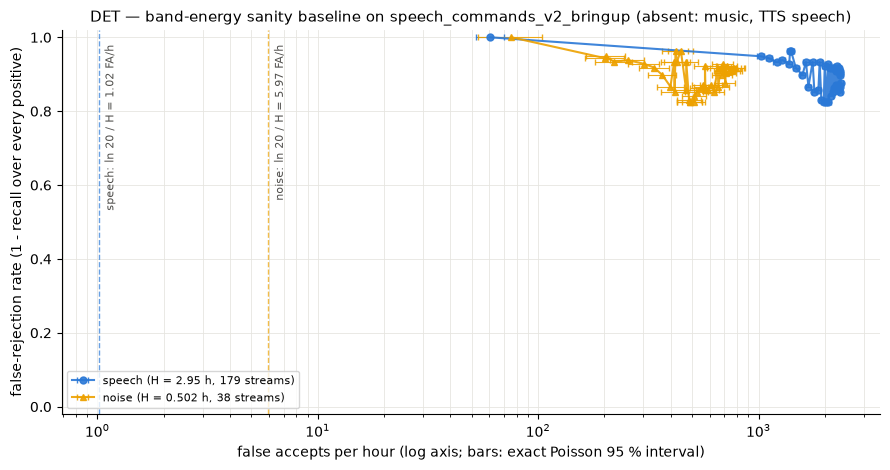

In [7]:
import matplotlib.pyplot as plt

SHARE_STYLE = {   # colour follows the share, in the report's column order, never the rank
    "eval-speech": ("speech", "#2a78d6", "o"), "eval-music": ("music", "#eb6834", "s"),
    "eval-tts": ("TTS speech", "#1baf7a", "D"), "eval-noise": ("noise", "#eda100", "^"),
}
present = [sh for sh in kws_eval.NEGATIVE_SHARES if sh in report.hours]
absent = [SHARE_STYLE[sh][0] for sh in kws_eval.NEGATIVE_SHARES if sh not in report.hours]
fig, ax = plt.subplots(figsize=(9, 4.8), dpi=100)
for sh in present:
    label, colour, marker = SHARE_STYLE[sh]
    H = report.hours[sh]
    rows = [(r.threshold, r.recall.frr, r.shares[sh]) for r in report.rows if r.recall.frr is not None]
    seen = [(f.fa_per_hour, frr, f.interval) for _, frr, f in rows if f.events > 0]
    unseen = [(f.zero_event_bound, frr) for _, frr, f in rows if f.events == 0]
    bound = kws_scoring.zero_event_bound(H)
    if seen:
        x = np.array([v[0] for v in seen]); y = np.array([v[1] for v in seen])
        lo = np.array([v[2][0] for v in seen]); hi = np.array([v[2][1] for v in seen])
        order = np.argsort(x)
        ax.errorbar(x[order], y[order], xerr=[x[order] - lo[order], hi[order] - x[order]], fmt=marker + "-",
                    color=colour, ecolor=colour, elinewidth=0.8, capsize=2, lw=1.5, ms=5, alpha=0.9,
                    label=f"{label} (H = {H:.3g} h, {report.negative_streams[sh]} streams)")
    if unseen:
        ax.plot([v[0] for v in unseen], [v[1] for v in unseen], marker="<", ls="none", mfc="none", mec=colour,
                ms=8, label=f"{label}: no event (rate <= ln 20 / H)")
    ax.axvline(bound, color=colour, ls="--", lw=1, alpha=0.7)
    ax.annotate(f"{label}: ln 20 / H = {bound:.2f} FA/h", xy=(bound, 0.98), xytext=(4, 0),
                textcoords="offset points", rotation=90, va="top", ha="left", fontsize=8, color="#52514e")
ax.set_xscale("log")
ax.set_ylim(-0.02, 1.02)
ax.set_xlabel("false accepts per hour (log axis; bars: exact Poisson 95 % interval)")
ax.set_ylabel("false-rejection rate (1 - recall over every positive)")
title = f"DET — band-energy sanity baseline on {manifest.name}"
if absent:
    title += f" (absent: {', '.join(absent)})"
ax.set_title(title, fontsize=11)
ax.grid(True, which="both", color="#e6e5e0", lw=0.6)
ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
ax.legend(fontsize=8, loc="lower left")
fig.tight_layout()
plt.show()

In [8]:
# what the curve says, in the numbers it was measured with (nothing below is typed by hand)
best = min((r for r in report.rows if r.recall.recall is not None), key=lambda r: r.recall.frr)
speech = "eval-speech"
print(f"positives: {report.positives}; thresholds swept: {len(report.rows)}")
for sh in present:
    H = report.hours[sh]
    print(f"{SHARE_STYLE[sh][0]}: H = {H:.4f} h, zero-event bound {kws_scoring.zero_event_bound(H):.3f} FA/h")
print(f"the baseline's best recall over the sweep: {best.recall.hits}/{best.recall.positives} = "
      f"{best.recall.recall:.3f} [{best.recall.interval[0]:.3f}, {best.recall.interval[1]:.3f}] at threshold "
      f"{best.threshold!r}, where FA/h speech = {kws_eval.format_fa(best.shares.get(speech))}")
under_1000 = [r for r in report.rows if speech in r.shares and r.shares[speech].fa_per_hour < 1000.0]
if under_1000:
    top = max(under_1000, key=lambda r: r.recall.recall)
    print(f"below 1000 FA/h on speech the best recall is {top.recall.hits}/{top.recall.positives} at "
          f"threshold {top.threshold!r} ({kws_eval.format_fa(top.shares[speech])})")
zero = report.rows[0]
print(f"threshold {zero.threshold!r}: every stream fires once at hop 0 (the t = 0 rule), so FA/h speech = "
      f"{kws_eval.format_fa(zero.shares.get(speech))} is the stream count over H, and recall is "
      f"{zero.recall.hits}/{zero.recall.positives} with {zero.spurious} spurious events")
earliest = min(scoring.hit_window(p.endpoint_hop)[0] for s in streams if s.share == "positives"
               for p in s.positives)
print(f"the earliest hit window on this corpus starts at hop {earliest}: hop 0 lies inside "
      f"{'no' if earliest > 0 else 'a'} window, which is why recall there is {zero.recall.hits}")
print(f"the plan's floors are >= 20 h of speech and >= 20 h of music (M4b's): this corpus has "
      + ", ".join(f"{SHARE_STYLE[sh][0]} {report.hours[sh]:.3f} h" for sh in present))
print(f"streams whose smoothed maximum reaches 1.0: {saturated} of {maxes.size}")
top = [r for r in report.rows if r.threshold >= 0.95]
print(f"the saturated end of the sweep, thresholds >= 0.95 ({len(top)} rows): speech events "
      f"{[r.shares[speech].events for r in top if speech in r.shares]}, hits "
      f"{[r.recall.hits for r in top]} of {report.rows[0].recall.positives}")

positives: {'eval-speech': 195}; thresholds swept: 44
speech: H = 2.9513 h, zero-event bound 1.015 FA/h
noise: H = 0.5021 h, zero-event bound 5.967 FA/h
the baseline's best recall over the sweep: 34/195 = 0.174 [0.128, 0.234] at threshold 0.3, where FA/h speech = 1977.11 [1926.70, 2028.50] (5835 in 2.951 h)
below 1000 FA/h on speech the best recall is 0/195 at threshold 0.0 (60.65 [52.09, 70.22] (179 in 2.951 h))
threshold 0.0: every stream fires once at hop 0 (the t = 0 rule), so FA/h speech = 60.65 [52.09, 70.22] (179 in 2.951 h) is the stream count over H, and recall is 0/195 with 195 spurious events
the earliest hit window on this corpus starts at hop 264: hop 0 lies inside no window, which is why recall there is 0
the plan's floors are >= 20 h of speech and >= 20 h of music (M4b's): this corpus has speech 2.951 h, noise 0.502 h
streams whose smoothed maximum reaches 1.0: 394 of 412
the saturated end of the sweep, thresholds >= 0.95 (5 rows): speech events [5592, 5195, 4844, 4141, 

## What this is, and what it is not

This is the **sanity curve** the plan's M5 asks for: the harness's plumbing — hop alignment, the hit
window, the refractory merge, the hours from decoded durations, the Poisson and Wilson intervals, the
per-share report — exercised end to end on real audio through the shipping front end. The pass is the
planted-event oracle in `test_kws_eval.py` (exact to the utterance, in CI); the curve above is *not* a
pass and *not* a performance claim. A band-energy mean has no notion of the keyword: its recall is what
loud speech at the right moment buys, and its false-accept rate is whatever the printed numbers above
say — read them, not the shape. Every figure in this cell's argument is printed by the code cell above
it, from `report`; nothing here is typed by hand.

Three things the curve makes visible that M6 inherits:

- **The hours.** The FA/h denominator is the eval negatives' decoded duration only; the positives'
  audio never counts. The hours per share and the zero-event bound ln 20 / *H* are printed above beside
  the plan's floors (≥ 20 h speech and ≥ 20 h music), which are M4b's: until they exist, no figure can
  distinguish a good detector from a lucky one below that bound.
- **The saturation.** The count of streams whose smoothed band-energy maximum reaches 1.0 is printed
  above; where most do, the quantile thresholds collapse and an even grid fills the sweep. A real
  spotter's scores are calibrated by its training and the quantiles spread on their own. Because the
  reference stage smooths with a trailing mean over *W* hops, the smoothed score reaches 1.0 only where
  all *W* frames sit at the baseline's clip, so the rows at the saturated end of the sweep (thresholds
  ≥ 0.95, their speech counts and hits printed above) select among fully saturated stretches and say
  nothing about a detector.
- **The threshold-0 row, and the packing.** Under the reference decision stage an event fires at hop 0
  when s[0] ≥ θ, and every stream is decided after a fresh reset, so θ = 0 fires exactly once per stream:
  FA/h = streams / *H*. Recall in that row is 0 wherever no hit window reaches hop 0 — the earliest window
  start on this corpus is printed above; a window includes hop 0 only when the endpoint lies within
  *T* + 1 hops of the stream start. streams / *H* is also the ceiling of what the negative-stream packing
  bound (`max_stream_s`, recorded in the report) can add to any FA/h row through the *t* = 0 rule and the
  refractory restart at each stream boundary. It is the rule, stated as a number, not a defect.

Absent negative shares read *absent* in the report and are named in the plot title; an absent hold-out
reads *absent* in the report's positives line. The report never prints 0 FA/h for hours that were not
scored. **The operating point is M6's**, chosen on dev, and its recall is measured on the recorded
hold-out alone (`kws_eval.py holdout`, which refuses a hold-out whose file hashes do not match
`holdout.json`); the eval-tts recall beside it is a descriptive gap figure, never a pass.